# **Assignment 2: Design and implement a Multilayer Perceptron (MLP) for classification of the Wine dataset, and evaluate its performance using accuracy and a confusion matrix.**

In [ ]:
# 1. Importing Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
# 2. Load the Wine Dataset
wine = load_wine()

X = wine.data
y = wine.target

print("Feature Shape :", X.shape)
print("Label Shape :", y.shape)
print("Target Classes :", wine.target_names)

Feature Shape : (178, 13)
Label Shape : (178,)
Target Classes : ['class_0' 'class_1' 'class_2']


In [ ]:
# 3. Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (142, 13)
Testing Samples : (36, 13)


In [ ]:
# 4. Normalize the Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 5. Build the MLP Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(13,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 6. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 7. Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.3186 - loss: 1.1259 - val_accuracy: 0.3793 - val_loss: 1.1049
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5310 - loss: 0.9805 - val_accuracy: 0.5862 - val_loss: 0.9743
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6460 - loss: 0.8585 - val_accuracy: 0.5862 - val_loss: 0.8660
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7699 - loss: 0.7573 - val_accuracy: 0.7931 - val_loss: 0.7754
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8230 - loss: 0.6714 - val_accuracy: 0.7931 - val_loss: 0.6956
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8673 - loss: 0.5948 - val_accuracy: 0.8276 - val_loss: 0.6236
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8850 - loss: 0.5268 - val_accuracy: 0.8276 - val_loss: 0.5575
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9027 - loss: 0.4657 - val_accuracy: 0.8621 - val_loss: 0.4984

In [ ]:
# 8. Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0200
Test Loss : 0.020032711327075958
Test Accuracy : 1.0


In [ ]:
# 9. Predict Classes
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [ ]:
# 10. Calculate Accuracy
acc = accuracy_score(y_test, predicted_classes)

print("Accuracy Score:", acc)

Accuracy Score: 1.0


In [ ]:
# 11. Classification Report
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    predicted_classes,
    target_names=wine.target_names
))


Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



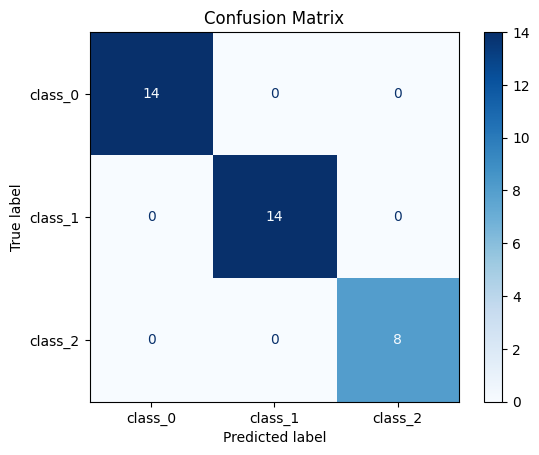

In [ ]:
# 12. Confusion Matrix
cm = confusion_matrix(y_test, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=wine.target_names
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

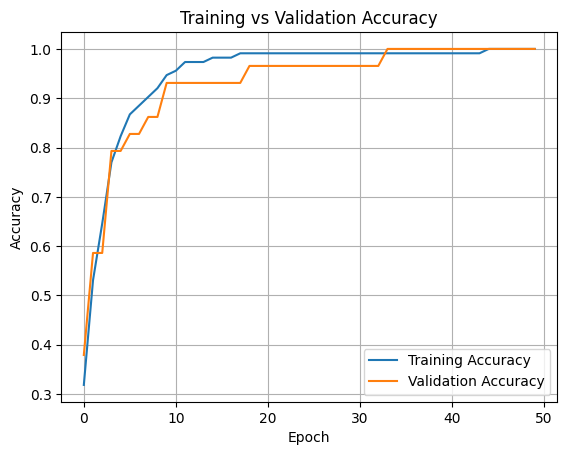

In [ ]:
# 13. Plot Training Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()